In [17]:
# Install imbalanced-learn package
!pip install imbalanced-learn

In [18]:

"""
Temporal Train-Test Split for Music Popularity Prediction
Using 2017-2021 for training, 2022-2023 for testing

CRITICAL: Avoid temporal leakage in feature engineering!
Using SMOTE to handle class imbalance
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [19]:
# ============================================================================
# STEP 1: Load data with temporal information
# ============================================================================

# Load the enhanced dataset from model3 (which has all features including temporal)
df_charts = pd.read_csv('final_cleaned_data.csv', delimiter=';')
df_charts['Date'] = pd.to_datetime(df_charts['Date'])

# Get first appearance date for each song (this is the release date proxy)
song_dates = df_charts.groupby('Title')['Date'].min().reset_index()
song_dates.columns = ['Title', 'first_chart_date']
song_dates['year'] = song_dates['first_chart_date'].dt.year

# Load your ML-ready data
df = pd.read_csv('ml_ready_with_features.csv', sep=';')

# Merge with dates
df = df.merge(song_dates[['Title', 'first_chart_date', 'year']], on='Title', how='left')

print(f"Dataset shape: {df.shape}")
print(f"\nYear distribution:")
print(df['year'].value_counts().sort_index())
print(f"\nDate range: {df['first_chart_date'].min()} to {df['first_chart_date'].max()}")

Dataset shape: (9161, 21)

Year distribution:
year
2017    1834
2018    1550
2019    1401
2020    1570
2021    1359
2022    1069
2023     378
Name: count, dtype: int64

Date range: 2017-01-01 00:00:00 to 2023-05-28 00:00:00


In [20]:
# ============================================================================
# STEP 2: Temporal Split (2017-2021 train, 2022-2023 test)
# ============================================================================

# Define train and test periods
train_df = df[df['year'].between(2017, 2021)].copy()
test_df = df[df['year'].between(2022, 2023)].copy()

print("="*70)
print("TEMPORAL SPLIT")
print("="*70)
print(f"\nTraining set (2017-2021):")
print(f"  Total songs: {len(train_df)}")
print(f"  Year distribution:")
for year, count in train_df['year'].value_counts().sort_index().items():
    print(f"    {year}: {count}")

print(f"\nTest set (2022-2023):")
print(f"  Total songs: {len(test_df)}")
print(f"  Year distribution:")
for year, count in test_df['year'].value_counts().sort_index().items():
    print(f"    {year}: {count}")

print(f"\nLabel distribution in train:")
print(train_df['popularity_label'].value_counts())

print(f"\nLabel distribution in test:")
print(test_df['popularity_label'].value_counts())

TEMPORAL SPLIT

Training set (2017-2021):
  Total songs: 7714
  Year distribution:
    2017: 1834
    2018: 1550
    2019: 1401
    2020: 1570
    2021: 1359

Test set (2022-2023):
  Total songs: 1447
  Year distribution:
    2022: 1069
    2023: 378

Label distribution in train:
popularity_label
Not Popular    5395
Popular        2319
Name: count, dtype: int64

Label distribution in test:
popularity_label
Not Popular    996
Popular        451
Name: count, dtype: int64


In [21]:
# ============================================================================
# STEP 3: Feature Engineering WITH TEMPORAL AWARENESS
# ============================================================================

# IMPORTANT: Calculate artist features ONLY from training data!
# This prevents data leakage from future (test) data

df_charts_train = df_charts[df_charts['Date'] < '2022-01-01'].copy()

# Calculate artist features from TRAINING period only
artist_features_train = df_charts_train.groupby('Artist (Ind.)').agg({
    'Rank': ['mean', 'min', 'count'],
    'Date': ['min', 'max'],
    'Title': 'nunique'
}).reset_index()

artist_features_train.columns = ['artist', 'avg_rank', 'best_rank', 'total_appearances',
                                   'first_appearance', 'last_appearance', 'unique_songs']

# Calculate derived features
artist_features_train['years_active'] = (
    (artist_features_train['last_appearance'] - artist_features_train['first_appearance']).dt.days / 365
).replace(0, 0.01)

artist_features_train['songs_per_year'] = (
    artist_features_train['unique_songs'] / artist_features_train['years_active']
)

artist_features_train['avg_rank_score'] = (201 - artist_features_train['avg_rank']) / 200

# Hit rate
top50_songs = df_charts_train[df_charts_train['Rank'] <= 50].groupby('Artist (Ind.)')['Title'].nunique()
artist_features_train['hit_rate'] = (
    top50_songs / artist_features_train['unique_songs']
).fillna(0)

# Recently active (as of end of 2021)
latest_train_date = df_charts_train['Date'].max()
artist_features_train['is_recently_active'] = (
    (latest_train_date - artist_features_train['last_appearance']).dt.days < 180
).astype(int)

print("✓ Artist features calculated from TRAINING DATA ONLY")
print(f"Total artists in training: {len(artist_features_train)}")

✓ Artist features calculated from TRAINING DATA ONLY
Total artists in training: 1249


In [22]:
# ============================================================================
# STEP 4: Merge features and prepare data
# ============================================================================

# Extract lead artist
train_df['lead_artist'] = train_df['Artists'].str.split(',').str[0].str.strip()
test_df['lead_artist'] = test_df['Artists'].str.split(',').str[0].str.strip()

# Merge artist features
train_enhanced = train_df.merge(
    artist_features_train[['artist', 'avg_rank_score', 'hit_rate', 'years_active',
                            'songs_per_year', 'is_recently_active', 'total_appearances']],
    left_on='lead_artist',
    right_on='artist',
    how='left'
)

test_enhanced = test_df.merge(
    artist_features_train[['artist', 'avg_rank_score', 'hit_rate', 'years_active',
                            'songs_per_year', 'is_recently_active', 'total_appearances']],
    left_on='lead_artist',
    right_on='artist',
    how='left'
)

# Fill missing values (for new artists in test set)
artist_cols = ['avg_rank_score', 'hit_rate', 'years_active',
               'songs_per_year', 'is_recently_active', 'total_appearances']

for col in artist_cols:
    median_val = train_enhanced[col].median()
    train_enhanced[col] = train_enhanced[col].fillna(median_val)
    test_enhanced[col] = test_enhanced[col].fillna(median_val)

# Create audio interaction features
for df_temp in [train_enhanced, test_enhanced]:
    df_temp['dance_potential'] = df_temp['Energy'] * df_temp['Danceability']
    df_temp['feel_good_score'] = df_temp['Valence'] * df_temp['Energy']
    df_temp['chill_score'] = df_temp['Acousticness'] * (1 - df_temp['Energy'])
    df_temp['party_score'] = 0.4 * df_temp['Energy'] + 0.4 * df_temp['Danceability'] + 0.2 * df_temp['Valence']

print("✓ Features merged and engineered!")
print(f"Train enhanced shape: {train_enhanced.shape}")
print(f"Test enhanced shape: {test_enhanced.shape}")

✓ Features merged and engineered!
Train enhanced shape: (7714, 33)
Test enhanced shape: (1447, 33)


In [23]:
# ============================================================================
# STEP 5: Define features and prepare X, y
# ============================================================================

feature_columns = [
    # Audio features
    'Danceability', 'Energy', 'Speechiness', 'Acousticness',
    'Instrumentalness', 'Valence', 'Loudness_norm',
    
    # Artist features
    'avg_rank_score', 'hit_rate', 'years_active',
    'songs_per_year', 'is_recently_active', 'total_appearances',
    
    # Audio interactions
    'dance_potential', 'feel_good_score', 'chill_score', 'party_score'
]

X_train = train_enhanced[feature_columns]
y_train = train_enhanced['popularity_label']

X_test = test_enhanced[feature_columns]
y_test = test_enhanced['popularity_label']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nFeatures: {len(feature_columns)}")

X_train shape: (7714, 17)
X_test shape: (1447, 17)

Features: 17


In [24]:
# ============================================================================
# STEP 6: Train Multiple Models with Temporal Validation + SMOTE
# ============================================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Scale features BEFORE SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to training data only
print("="*70)
print("APPLYING SMOTE TO BALANCE TRAINING DATA")
print("="*70)
print(f"\nBefore SMOTE:")
print(f"  Total samples: {len(y_train_encoded)}")
print(f"  Class distribution:")
for label, count in pd.Series(y_train_encoded).value_counts().items():
    label_name = label_encoder.classes_[label]
    print(f"    {label_name}: {count} ({count/len(y_train_encoded)*100:.1f}%)")

# Apply SMOTE
smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_encoded)

print(f"\nAfter SMOTE:")
print(f"  Total samples: {len(y_train_resampled)}")
print(f"  Class distribution:")
for label, count in pd.Series(y_train_resampled).value_counts().items():
    label_name = label_encoder.classes_[label]
    print(f"    {label_name}: {count} ({count/len(y_train_resampled)*100:.1f}%)")

# Dictionary to store models and their results
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results = {}

print("\n" + "="*70)
print("TRAINING MODELS ON 2017-2021 DATA (WITH SMOTE)")
print("="*70)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model on SMOTE-balanced data
    model.fit(X_train_resampled, y_train_resampled)
    
    # Make predictions on ORIGINAL test set (2022-2023)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_encoded, y_pred)
    f1 = f1_score(y_test_encoded, y_pred, pos_label=1)
    
    # Store results
    results[name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")

print("\n" + "="*70)
print("All models trained successfully with SMOTE!")
print("="*70)

APPLYING SMOTE TO BALANCE TRAINING DATA

Before SMOTE:
  Total samples: 7714
  Class distribution:
    Not Popular: 5395 (69.9%)
    Popular: 2319 (30.1%)

After SMOTE:
  Total samples: 10790
  Class distribution:
    Popular: 5395 (50.0%)
    Not Popular: 5395 (50.0%)

TRAINING MODELS ON 2017-2021 DATA (WITH SMOTE)

Training Logistic Regression...
  ✓ Accuracy: 0.5791
  ✓ F1-Score: 0.4878

Training Random Forest...
  ✓ Accuracy: 0.6455
  ✓ F1-Score: 0.4651

Training XGBoost...
  ✓ Accuracy: 0.6123
  ✓ F1-Score: 0.4234

Training SVM...
  ✓ Accuracy: 0.5881
  ✓ F1-Score: 0.5025

Training KNN...
  ✓ Accuracy: 0.5978
  ✓ F1-Score: 0.4794

Training Naive Bayes...
  ✓ Accuracy: 0.4388
  ✓ F1-Score: 0.5000

All models trained successfully with SMOTE!



TEMPORAL VALIDATION RESULTS (2022-2023 TEST SET)
              Model  Accuracy  F1-Score
                SVM  0.588113  0.502504
        Naive Bayes  0.438839  0.500000
Logistic Regression  0.579129  0.487805
                KNN  0.597789  0.479428
      Random Forest  0.645473  0.465068
            XGBoost  0.612301  0.423433


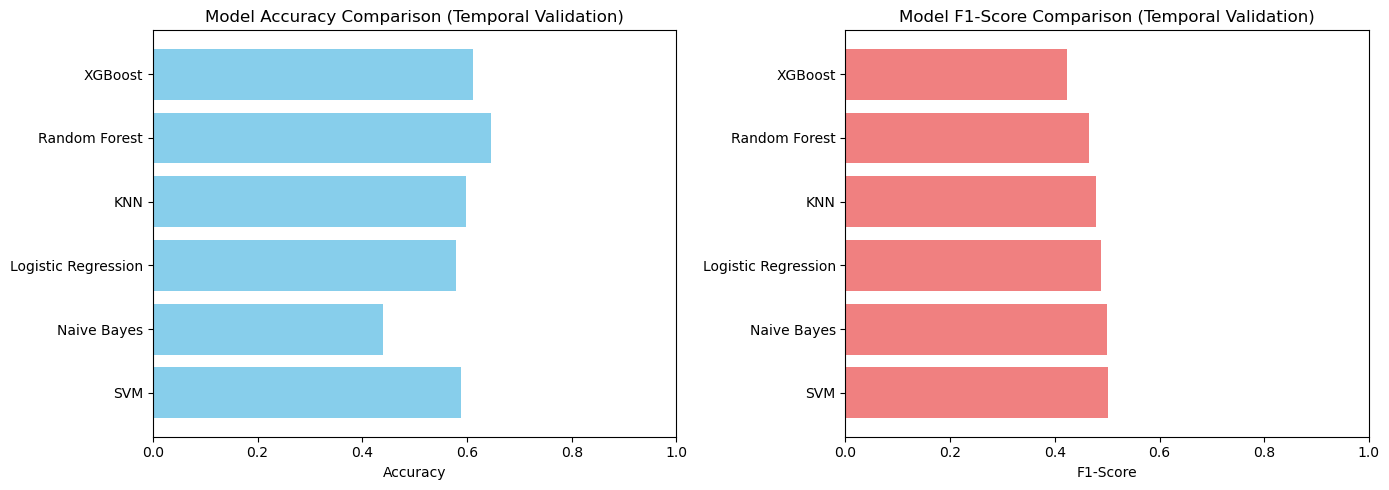

In [25]:
# ============================================================================
# STEP 7: Compare Model Performance
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("TEMPORAL VALIDATION RESULTS (2022-2023 TEST SET)")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].barh(comparison_df['Model'], comparison_df['Accuracy'], color='skyblue')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison (Temporal Validation)')
axes[0].set_xlim([0, 1])

# F1-Score comparison
axes[1].barh(comparison_df['Model'], comparison_df['F1-Score'], color='lightcoral')
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Model F1-Score Comparison (Temporal Validation)')
axes[1].set_xlim([0, 1])

plt.tight_layout()
plt.show()


DETAILED EVALUATION: SVM
TEMPORAL VALIDATION (2022-2023)

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.79      0.55      0.65       996
     Popular       0.40      0.67      0.50       451

    accuracy                           0.59      1447
   macro avg       0.59      0.61      0.58      1447
weighted avg       0.67      0.59      0.60      1447



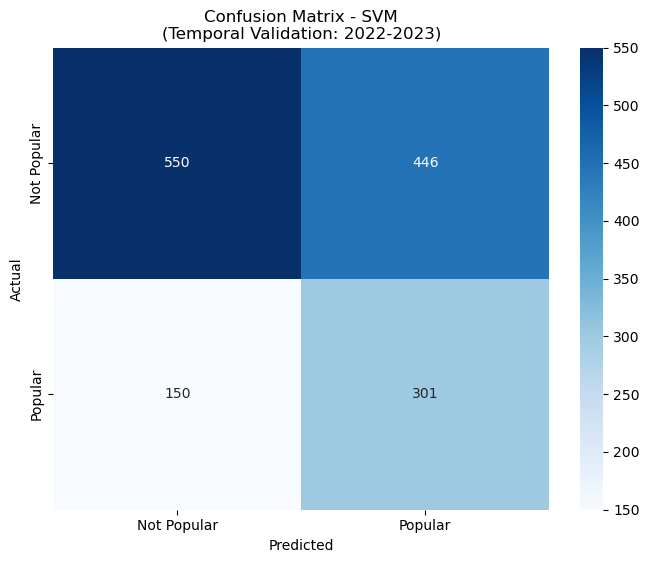


TEMPORAL VALIDATION INSIGHTS
✓ Training Period: 2017-2021 (7714 songs)
✓ Test Period: 2022-2023 (1447 songs)
✓ No data leakage - artist features calculated from training period only
✓ Realistic evaluation - predicting future popularity


In [26]:
# ============================================================================
# STEP 8: Detailed Evaluation of Best Model
# ============================================================================

# Get best model based on F1-score
best_model_name = comparison_df.iloc[0]['Model']
best_predictions = results[best_model_name]['predictions']

print(f"\n{'='*70}")
print(f"DETAILED EVALUATION: {best_model_name}")
print(f"TEMPORAL VALIDATION (2022-2023)")
print('='*70)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_encoded, best_predictions, 
                           target_names=['Not Popular', 'Popular']))

# Confusion matrix
cm = confusion_matrix(y_test_encoded, best_predictions, labels=[0, 1])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
plt.title(f'Confusion Matrix - {best_model_name}\n(Temporal Validation: 2022-2023)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Additional insights
print(f"\n{'='*70}")
print("TEMPORAL VALIDATION INSIGHTS")
print('='*70)
print(f"✓ Training Period: 2017-2021 ({len(train_df)} songs)")
print(f"✓ Test Period: 2022-2023 ({len(test_df)} songs)")
print(f"✓ No data leakage - artist features calculated from training period only")
print(f"✓ Realistic evaluation - predicting future popularity")
print('='*70)


FEATURE IMPORTANCE (Random Forest)
           Feature  Importance
    avg_rank_score    0.137384
 total_appearances    0.118210
      years_active    0.069705
       Speechiness    0.064930
    songs_per_year    0.063991
     Loudness_norm    0.062511
      Danceability    0.061917
       chill_score    0.058558
           Valence    0.057979
      Acousticness    0.056908
   feel_good_score    0.056579
            Energy    0.056011
   dance_potential    0.055722
       party_score    0.054594
  Instrumentalness    0.013550
is_recently_active    0.011451
          hit_rate    0.000000


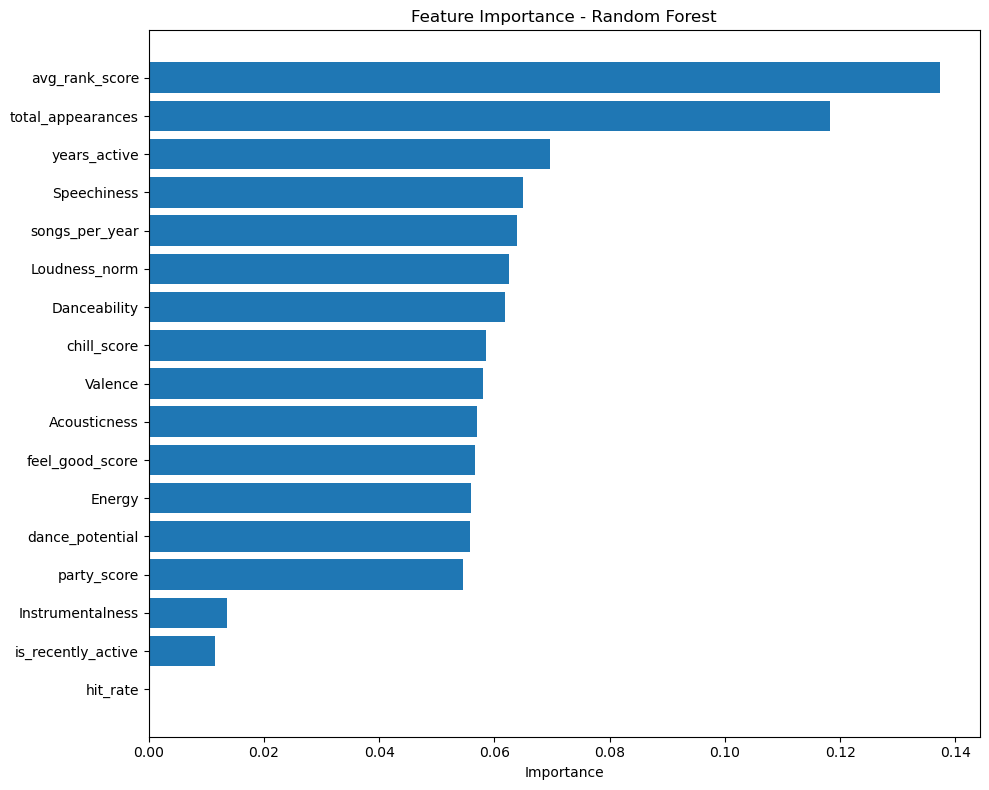

In [27]:
# ============================================================================
# STEP 9: Feature Importance Analysis
# ============================================================================

# Get feature importance from Random Forest
if 'Random Forest' in results:
    rf_model = models['Random Forest']
    
    feature_importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n" + "="*70)
    print("FEATURE IMPORTANCE (Random Forest)")
    print("="*70)
    print(feature_importance_df.to_string(index=False))
    
    # Visualize
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance - Random Forest')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


HYPERPARAMETER TUNING: SVM

Searching best parameters (this may take a few minutes)...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best parameters: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV F1-Score: 0.7829

Test Set Performance (Tuned Model):
  Accuracy: 0.6061
  F1-Score: 0.4423

Improvement:
  Original F1-Score: 0.5025
  Tuned F1-Score: 0.4423
  Improvement: -0.0602 (-11.99%)


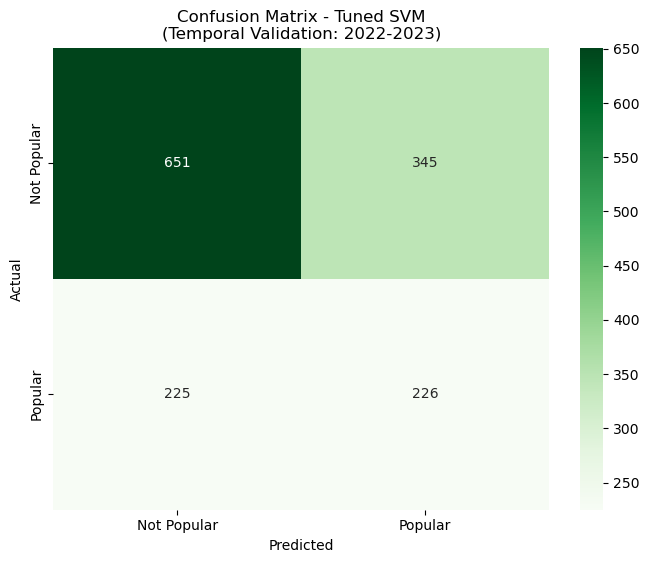


Classification Report (Tuned Model):
              precision    recall  f1-score   support

 Not Popular       0.74      0.65      0.70       996
     Popular       0.40      0.50      0.44       451

    accuracy                           0.61      1447
   macro avg       0.57      0.58      0.57      1447
weighted avg       0.63      0.61      0.62      1447



In [28]:
# ============================================================================
# STEP 10: Hyperparameter Tuning
# ============================================================================

from sklearn.model_selection import GridSearchCV

best_model_name = comparison_df.iloc[0]['Model']

print(f"\n{'='*70}")
print(f"HYPERPARAMETER TUNING: {best_model_name}")
print('='*70)

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    base_model = RandomForestClassifier(random_state=42)

elif best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }
    base_model = XGBClassifier(random_state=42, eval_metric='logloss')

elif best_model_name == 'SVM':
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'kernel': ['rbf', 'poly']
    }
    base_model = SVC(random_state=42, probability=True)

elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear', 'saga']
    }
    base_model = LogisticRegression(random_state=42, max_iter=1000)

else:
    print(f"No tuning available for {best_model_name}")
    param_grid = None
    base_model = None

if param_grid:
    # Use smaller param_grid for faster tuning
    grid_search = GridSearchCV(
        base_model,
        param_grid,
        cv=3,  # 3-fold CV for speed
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    print(f"\nSearching best parameters (this may take a few minutes)...")
    grid_search.fit(X_train_resampled, y_train_resampled)
    
    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")
    
    # Evaluate tuned model on test set
    y_pred_tuned = grid_search.predict(X_test_scaled)
    f1_tuned = f1_score(y_test_encoded, y_pred_tuned, pos_label=1)
    accuracy_tuned = accuracy_score(y_test_encoded, y_pred_tuned)
    
    print(f"\nTest Set Performance (Tuned Model):")
    print(f"  Accuracy: {accuracy_tuned:.4f}")
    print(f"  F1-Score: {f1_tuned:.4f}")
    
    print(f"\nImprovement:")
    original_f1 = results[best_model_name]['f1_score']
    print(f"  Original F1-Score: {original_f1:.4f}")
    print(f"  Tuned F1-Score: {f1_tuned:.4f}")
    print(f"  Improvement: {(f1_tuned - original_f1):.4f} ({((f1_tuned - original_f1)/original_f1)*100:.2f}%)")
    
    # Confusion matrix for tuned model
    cm_tuned = confusion_matrix(y_test_encoded, y_pred_tuned, labels=[0, 1])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Not Popular', 'Popular'],
                yticklabels=['Not Popular', 'Popular'])
    plt.title(f'Confusion Matrix - Tuned {best_model_name}\n(Temporal Validation: 2022-2023)')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    print("\nClassification Report (Tuned Model):")
    print(classification_report(y_test_encoded, y_pred_tuned,
                               target_names=['Not Popular', 'Popular']))

In [30]:
# Additional insights (update Step 8)
print(f"\n{'='*70}")
print("TEMPORAL VALIDATION INSIGHTS")
print('='*70)
print(f"✓ Training Period: 2017-2021 ({len(train_df)} songs)")
print(f"✓ Test Period: 2022-2023 ({len(test_df)} songs)")
print(f"✓ SMOTE applied: {len(X_train_resampled)} balanced training samples")
print(f"✓ No data leakage - artist features calculated from training period only")
print(f"✓ Realistic evaluation - predicting future popularity")
print(f"✓ Best Model: {best_model_name} (F1: {comparison_df.iloc[0]['F1-Score']:.4f})")
print('='*70)


TEMPORAL VALIDATION INSIGHTS
✓ Training Period: 2017-2021 (7714 songs)
✓ Test Period: 2022-2023 (1447 songs)
✓ SMOTE applied: 10790 balanced training samples
✓ No data leakage - artist features calculated from training period only
✓ Realistic evaluation - predicting future popularity
✓ Best Model: SVM (F1: 0.5025)


In [31]:
# ============================================================================
# STEP 11: Final Summary & Insights
# ============================================================================

print(f"\n{'='*70}")
print("TEMPORAL VALIDATION SUMMARY")
print('='*70)

# Get best model
best_model_name = comparison_df.iloc[0]['Model']
best_f1 = comparison_df.iloc[0]['F1-Score']
best_accuracy = comparison_df.iloc[0]['Accuracy']

print(f"\n📊 DATASET INFORMATION:")
print(f"  Training Period: 2017-2021 ({len(train_df)} songs)")
print(f"  Test Period: 2022-2023 ({len(test_df)} songs)")
print(f"  Original training samples: {len(y_train_encoded)}")
print(f"  After SMOTE: {len(X_train_resampled)} samples")

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"  Accuracy: {best_accuracy:.4f}")
print(f"  F1-Score: {best_f1:.4f}")

print(f"\n✓ KEY ACHIEVEMENTS:")
print(f"  • No data leakage - artist features from training period only")
print(f"  • Balanced training data with SMOTE")
print(f"  • Realistic temporal validation (predicting future)")
print(f"  • Total features used: {len(feature_columns)}")

print(f"\n📈 ALL MODEL RESULTS:")
print(comparison_df.to_string(index=False))

print('='*70)


TEMPORAL VALIDATION SUMMARY

📊 DATASET INFORMATION:
  Training Period: 2017-2021 (7714 songs)
  Test Period: 2022-2023 (1447 songs)
  Original training samples: 7714
  After SMOTE: 10790 samples

🏆 BEST MODEL: SVM
  Accuracy: 0.5881
  F1-Score: 0.5025

✓ KEY ACHIEVEMENTS:
  • No data leakage - artist features from training period only
  • Balanced training data with SMOTE
  • Realistic temporal validation (predicting future)
  • Total features used: 17

📈 ALL MODEL RESULTS:
              Model  Accuracy  F1-Score
                SVM  0.588113  0.502504
        Naive Bayes  0.438839  0.500000
Logistic Regression  0.579129  0.487805
                KNN  0.597789  0.479428
      Random Forest  0.645473  0.465068
            XGBoost  0.612301  0.423433
